In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import export_text
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, confusion_matrix, classification_report
from scipy import stats
from sklearn import metrics

In [2]:
data = pd.read_csv('marketing.csv')
data

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response,result
0,13829,29,technician,single,tertiary,no,18254,no,no,cellular,11,may,2,-1,0,unknown,no
1,22677,26,services,single,secondary,no,512,yes,yes,unknown,5,jun,3,-1,0,unknown,no
2,10541,30,management,single,secondary,no,135,no,no,cellular,14,aug,2,-1,0,unknown,no
3,13689,41,technician,married,unknown,no,30,yes,no,cellular,10,jul,1,-1,0,unknown,no
4,11304,27,admin.,single,secondary,no,321,no,yes,unknown,2,sep,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,14023,47,technician,married,secondary,no,1167,yes,no,cellular,30,apr,1,87,5,failure,yes
12866,17259,31,unknown,married,secondary,no,111,no,no,cellular,21,nov,2,93,2,failure,yes
12867,15200,37,unemployed,single,tertiary,no,1316,yes,no,cellular,18,nov,1,172,2,failure,no
12868,13775,42,management,married,tertiary,no,479,yes,no,unknown,28,may,2,-1,0,unknown,no


In [3]:
data['result'] = np.where(data['result']=='yes', 0, 1)
data

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response,result
0,13829,29,technician,single,tertiary,no,18254,no,no,cellular,11,may,2,-1,0,unknown,1
1,22677,26,services,single,secondary,no,512,yes,yes,unknown,5,jun,3,-1,0,unknown,1
2,10541,30,management,single,secondary,no,135,no,no,cellular,14,aug,2,-1,0,unknown,1
3,13689,41,technician,married,unknown,no,30,yes,no,cellular,10,jul,1,-1,0,unknown,1
4,11304,27,admin.,single,secondary,no,321,no,yes,unknown,2,sep,1,-1,0,unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,14023,47,technician,married,secondary,no,1167,yes,no,cellular,30,apr,1,87,5,failure,0
12866,17259,31,unknown,married,secondary,no,111,no,no,cellular,21,nov,2,93,2,failure,0
12867,15200,37,unemployed,single,tertiary,no,1316,yes,no,cellular,18,nov,1,172,2,failure,1
12868,13775,42,management,married,tertiary,no,479,yes,no,unknown,28,may,2,-1,0,unknown,1


In [4]:
data.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,12870.0,NaN,NaN,NaN,16434.5,3715.393317,10000.0,13217.25,16434.5,19651.75,22869.0
age,12870.0,NaN,NaN,NaN,41.091142,11.30556,18.0,32.0,39.0,49.0,95.0
job,12870,12,management,2858,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,12870,3,married,7490,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,12870,4,secondary,6368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,12870,2,no,12662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,12870.0,NaN,NaN,NaN,1483.774437,3311.055181,-6847.0,102.0,515.0,1591.75,102127.0
housing,12870,2,yes,6605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,12870,2,no,11060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,12870,3,cellular,8756,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
for i in data.columns:
    print(data[i].value_counts())

ID
13829    1
22677    1
10541    1
13689    1
11304    1
        ..
14023    1
17259    1
15200    1
13775    1
20137    1
Name: count, Length: 12870, dtype: int64
age
32    569
33    565
31    545
34    533
36    526
     ... 
87      2
89      2
88      1
95      1
92      1
Name: count, Length: 76, dtype: int64
job
management       2858
blue-collar      2571
technician       2141
admin.           1464
services         1043
retired           770
self-employed     454
unemployed        414
entrepreneur      383
student           358
housemaid         334
unknown            80
Name: count, dtype: int64
marital
married     7490
single      3905
divorced    1475
Name: count, dtype: int64
education
secondary    6368
tertiary     4075
primary      1880
unknown       547
Name: count, dtype: int64
default
no     12662
yes      208
Name: count, dtype: int64
balance
 0       924
 1        52
 2        49
 4        40
 3        39
        ... 
-1636      1
 2807      1
 2988      1
 1110      

In [6]:
data.drop('ID', axis=1, inplace=True)
data.drop('pdays', axis=1, inplace=True)
data.drop('previous', axis=1, inplace=True)

In [7]:
for i in data.columns:
    if not pd.api.types.is_numeric_dtype(data[i]):
        print(i)

job
marital
education
default
housing
loan
contact
month
response


In [9]:
le = LabelEncoder()

for i in data.columns:
    if not pd.api.types.is_numeric_dtype(data[i]):
       data[i] = le.fit_transform(data[i])

data.describe(include='all').transpose()

,count,mean,std,min,25%,50%,75%,max
age,12870.0,41.091142,11.305560,18.0,32.0,39.0,49.00,95.0
job,12870.0,4.413287,3.254204,0.0,1.0,4.0,7.00,11.0
marital,12870.0,1.188811,0.618390,0.0,1.0,1.0,2.00,2.0
education,12870.0,1.255556,0.753291,0.0,1.0,1.0,2.00,3.0
default,12870.0,0.016162,0.126102,0.0,0.0,0.0,0.00,1.0
balance,12870.0,1483.774437,3311.055181,-6847.0,102.0,515.0,1591.75,102127.0
housing,12870.0,0.513209,0.499845,0.0,0.0,1.0,1.00,1.0
loan,12870.0,0.140637,0.347660,0.0,0.0,0.0,0.00,1.0
contact,12870.0,0.571329,0.865050,0.0,0.0,0.0,2.00,2.0
day,12870.0,15.641103,8.368983,1.0,8.0,16.0,21.00,31.0


In [10]:
X = data.drop('result', axis=1)
y = data['result']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [12]:
def evaluate(model, X_train, y_train, X_test, y_test):
    
    '''Predictions and probabilities for the training set'''
    
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    '''Predictions and probabilities for the test set'''
    
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    '''Calculate metrics for the training set''' 
    
    roc_train_prob = roc_auc_score(y_train, y_train_prob)
    gini_train_prob = roc_train_prob * 2 - 1
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)

    '''Calculate metrics for the test set'''
    
    roc_test_prob = roc_auc_score(y_test, y_test_prob)
    gini_test_prob = roc_test_prob * 2 - 1
    precision_test = precision_score(y_test, y_test_pred)
    recall_test = recall_score(y_test, y_test_pred)

    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Gini': [gini_train_prob * 100, gini_test_prob * 100],
        'Precision': [precision_train, precision_test],
        'Recall': [recall_train, recall_test]
    })

    return results

In [13]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
result = evaluate(rfc, X_train, y_train, X_test, y_test)
result

,Dataset,Gini,Precision,Recall
0,Train,100.000000,1.000000,1.000000
1,Test,53.637075,0.800325,0.913978


In [15]:
def plot_feature_importances(model, feature_names):
    
    importances = model.feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by="Importance", ascending=False)
   
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.title("Feature Importances")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis() 
    plt.show()
    
    return importance_df

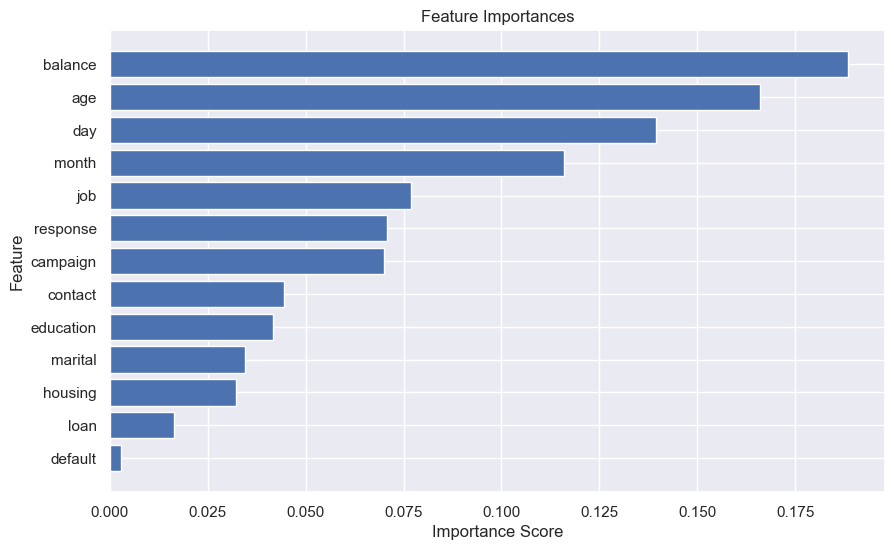

,Feature,Importance
5,balance,0.188503
0,age,0.166062
9,day,0.139418
10,month,0.115948
1,job,0.076943
12,response,0.070649
11,campaign,0.070068
8,contact,0.044553
3,education,0.041726
2,marital,0.034535


In [16]:
feature_names = X_train.columns

feature_importance_df = plot_feature_importances(rfc, feature_names)

feature_importance_df

In [17]:
feature_importance_df.Feature.tolist()

['balance',
 'age',
 'day',
 'month',
 'job',
 'response',
 'campaign',
 'contact',
 'education',
 'marital',
 'housing',
 'loan',
 'default']

In [18]:
clfRF_selected = RandomForestClassifier(random_state=42)

clfRF_selected.fit(X_train[['balance','age', 'day', 'month', 'job', 'response', 'campaign']],y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
result = evaluate(clfRF_selected, X_train[['balance','age', 'day', 'month', 'job', 'response', 'campaign']], y_train,
                  X_test[['balance','age', 'day', 'month', 'job', 'response', 'campaign']], y_test)
result

,Dataset,Gini,Precision,Recall
0,Train,100.000000,1.000000,1.000000
1,Test,46.894698,0.788209,0.912125


In [20]:
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 1000, num = 10)]
max_depth = [int(x) for x in np.linspace(10, 100, num = 11)]


random_grid = {'n_estimators': n_estimators, 
               'max_features': ['sqrt', 0.3, 0.5, None], 
               'max_depth': max_depth, 
               'min_samples_split': [20,50], 
               'min_samples_leaf': [5, 8, 10]} 
print(random_grid)

{'n_estimators': [200, 288, 377, 466, 555, 644, 733, 822, 911, 1000], 'max_features': ['sqrt', 0.3, 0.5, None], 'max_depth': [10, 19, 28, 37, 46, 55, 64, 73, 82, 91, 100], 'min_samples_split': [20, 50], 'min_samples_leaf': [5, 8, 10]}


In [21]:
rf_random = RandomizedSearchCV(
                    estimator=rfc, 
                    param_distributions=random_grid, 
                    n_iter=10,  
                    cv=5, 
                    verbose=1, 
                    random_state=54, 
                    n_jobs=-1)


rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 19, ...], 'max_features': ['sqrt', 0.3, ...], 'min_samples_leaf': [5, 8, ...], 'min_samples_split': [20, 50], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [22]:
rf_random.best_params_

{'n_estimators': 377,
 'min_samples_split': 50,
 'min_samples_leaf': 5,
 'max_features': 0.5,
 'max_depth': 55}

In [23]:
optimized_model = rf_random.best_estimator_


evaluate(optimized_model, X_train, y_train, X_test, y_test)

,Dataset,Gini,Precision,Recall
0,Train,76.906493,0.810369,0.934418
1,Test,55.207262,0.798918,0.931034


# Deployment

In [25]:
data_deploy = pd.read_excel('marketing_test.xlsx')
data_deploy

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response
0,812,25,blue-collar,single,secondary,no,764,yes,no,cellular,18,may,1,-1,0,unknown
1,71,40,blue-collar,single,primary,no,118,no,no,unknown,23,feb,1,-1,0,unknown
2,912,27,admin.,divorced,secondary,no,451,yes,no,cellular,16,jul,1,-1,0,unknown
3,43,30,services,single,secondary,no,495,yes,no,cellular,21,nov,1,-1,0,unknown
4,431,36,blue-collar,married,primary,no,1548,yes,yes,cellular,18,may,2,-1,0,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,49,43,blue-collar,married,secondary,no,413,yes,no,cellular,12,aug,2,182,4,success
853,409,56,management,married,tertiary,no,1282,no,no,cellular,19,aug,4,-1,0,unknown
854,105,54,admin.,married,primary,no,976,yes,no,unknown,3,jun,3,-1,0,unknown
855,810,30,unemployed,single,tertiary,no,1159,no,no,telephone,5,jun,1,-1,0,unknown


In [26]:
data_deploy.describe(include='all')

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response
count,857.000000,857.000000,857,857,857,857,857.000000,857,857,857,857.000000,857,857.000000,857.000000,857.000000,857
unique,NaN,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,4
top,NaN,NaN,management,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,unknown
freq,NaN,NaN,184,480,422,837,NaN,461,753,590,NaN,251,NaN,NaN,NaN,663
mean,500.905484,40.213536,NaN,NaN,NaN,NaN,1512.206534,NaN,NaN,NaN,15.709452,NaN,2.560093,45.292882,0.723454,NaN
std,291.755233,10.970964,NaN,NaN,NaN,NaN,3298.422298,NaN,NaN,NaN,8.382548,NaN,2.593836,100.537548,1.963885,NaN
min,1.000000,18.000000,NaN,NaN,NaN,NaN,-2604.000000,NaN,NaN,NaN,1.000000,NaN,1.000000,-1.000000,0.000000,NaN
25%,247.000000,32.000000,NaN,NaN,NaN,NaN,112.000000,NaN,NaN,NaN,8.000000,NaN,1.000000,-1.000000,0.000000,NaN
50%,496.000000,38.000000,NaN,NaN,NaN,NaN,523.000000,NaN,NaN,NaN,16.000000,NaN,2.000000,-1.000000,0.000000,NaN
75%,758.000000,47.000000,NaN,NaN,NaN,NaN,1624.000000,NaN,NaN,NaN,22.000000,NaN,3.000000,-1.000000,0.000000,NaN


In [27]:
for i in data_deploy.columns:
    if not pd.api.types.is_numeric_dtype(data_deploy[i]):
       data_deploy[i] = le.fit_transform(data_deploy[i])

data_deploy.describe(include='all').transpose()

,count,mean,std,min,25%,50%,75%,max
ID,857.0,500.905484,291.755233,1.0,247.0,496.0,758.0,999.0
age,857.0,40.213536,10.970964,18.0,32.0,38.0,47.0,83.0
job,857.0,4.458576,3.326610,0.0,1.0,4.0,8.0,11.0
marital,857.0,1.234539,0.620764,0.0,1.0,1.0,2.0,2.0
education,857.0,1.241540,0.744921,0.0,1.0,1.0,2.0,3.0
default,857.0,0.023337,0.151060,0.0,0.0,0.0,0.0,1.0
balance,857.0,1512.206534,3298.422298,-2604.0,112.0,523.0,1624.0,45248.0
housing,857.0,0.537923,0.498851,0.0,0.0,1.0,1.0,1.0
loan,857.0,0.121354,0.326728,0.0,0.0,0.0,0.0,1.0
contact,857.0,0.558926,0.861477,0.0,0.0,0.0,1.0,2.0


In [29]:
inputs_deploy = data_deploy.drop(['ID', 'pdays', 'previous'], axis=1)

In [31]:
data_deploy['Probability of Interest'] = rf_random.predict_proba(inputs_deploy)[:,1]
data_deploy

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,response,Score,Probability of Interest
0,812,25,1,2,1,0,764,1,0,0,18,8,1,-1,0,3,0.543713,0.543713
1,71,40,1,2,0,0,118,0,0,2,23,3,1,-1,0,3,0.794125,0.794125
2,912,27,0,0,1,0,451,1,0,0,16,5,1,-1,0,3,0.540629,0.540629
3,43,30,7,2,1,0,495,1,0,0,21,9,1,-1,0,3,0.619886,0.619886
4,431,36,1,1,0,0,1548,1,1,0,18,8,2,-1,0,3,0.813343,0.813343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,49,43,1,1,1,0,413,1,0,0,12,1,2,182,4,2,0.243840,0.243840
853,409,56,4,1,2,0,1282,0,0,0,19,1,4,-1,0,3,0.719656,0.719656
854,105,54,0,1,0,0,976,1,0,2,3,6,3,-1,0,3,0.943432,0.943432
855,810,30,10,2,2,0,1159,0,0,1,5,6,1,-1,0,3,0.414206,0.414206
